## Ансамбли и полносвязные нейронные сети
В этом ноутбуке вам нужно обучить модели на датасете классификации из предыдущего ноутбука и сравнить результаты. Вам будет предоставлен baseline, на основе которого вы будете доделывать предсказывающие модели. Оценка лабы будет зависеть от ROC-AUC на тестовых данных по следующим критериям:
\
AUC - на тестовых данных
- $AUC \leq 0.76$ - 0 баллов
- $0.76 < AUC \leq 0.77$ - 2 балла
- $0.77 < AUC \leq 0.78$ - 4 балла
- $0.78 < AUC \leq 0.79$ - 6 баллов
- $0.79 < AUC \leq 0.80$ - 8 баллов
- $AUC > 0.80$ - 10 баллов


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, classification_report

# ансамбли и нейронные сети
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
data = pd.read_csv('german.csv', sep=';')
print("Размер данных:", data.shape)
data.head()

Размер данных: (1000, 21)


,Creditability,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,...,Duration_in_Current_address,Most_valuable_available_asset,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,No_of_dependents,Telephone,Foreign_Worker
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,2


In [2]:
# Целевая переменная
X = data.drop('Creditability', axis=1)
y = data['Creditability']

# Стратифицированное разбиение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Доля класса 1 в обучающей выборке: {y_train.mean():.3f}")
print(f"Доля класса 1 в тестовой выборке: {y_test.mean():.3f}")

# Определение категориальных признаков
n_unique = X_train.nunique()
print("Количество уникальных значений в признаках:")
print(n_unique.sort_values())

cat_features = n_unique[n_unique <= 10].index.tolist()
num_features = [col for col in X.columns if col not in cat_features]

print("\nКатегориальные признаки:", cat_features)
print("Числовые признаки:", num_features)

# Предобработка для MLP
preprocessor_mlp = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
    ])

Размер обучающей выборки: (800, 20)
Размер тестовой выборки: (200, 20)
Доля класса 1 в обучающей выборке: 0.700
Доля класса 1 в тестовой выборке: 0.700
Количество уникальных значений в признаках:
Telephone                              2
Foreign_Worker                         2
No_of_dependents                       2
Concurrent_Credits                     3
Guarantors                             3
Type_of_apartment                      3
Sex_Marital_Status                     4
Account_Balance                        4
No_of_Credits_at_this_Bank             4
Instalment_per_cent                    4
Duration_in_Current_address            4
Most_valuable_available_asset          4
Occupation                             4
Value_Savings_Stocks                   5
Payment_Status_of_Previous_Credit      5
Length_of_current_employment           5
Purpose                               10
Duration_of_Credit_monthly            31
Age_years                             53
Credit_Amount            

In [3]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    
    print(f"{model_name}:")
    print(f"  ROC-AUC: {auc:.4f}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall: {rec:.4f}")
    return auc, y_proba

print("=== Baseline модели (без предобработки) ===")
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
gb_base = GradientBoostingClassifier(n_estimators=100, random_state=42)
mlp_base = MLPClassifier(hidden_layer_sizes=(30,), max_iter=500, random_state=42)

evaluate_model(rf_base, X_train, y_train, X_test, y_test, "Random Forest (базовый)")
evaluate_model(gb_base, X_train, y_train, X_test, y_test, "Gradient Boosting (базовый)")
evaluate_model(mlp_base, X_train, y_train, X_test, y_test, "MLP (базовый)")

=== Baseline модели (без предобработки) ===
Random Forest (базовый):
  ROC-AUC: 0.8158
  Accuracy: 0.8050
  Precision: 0.8137
  Recall: 0.9357
Gradient Boosting (базовый):
  ROC-AUC: 0.8198
  Accuracy: 0.7900
  Precision: 0.8267
  Recall: 0.8857
MLP (базовый):
  ROC-AUC: 0.6525
  Accuracy: 0.7150
  Precision: 0.7107
  Recall: 1.0000


(0.6525000000000001,
 array([0.65584466, 0.92769352, 0.96225169, 0.97703166, 0.44552961,
        0.96977888, 0.6668365 , 0.7458975 , 0.78947779, 0.98981873,
        0.83962773, 0.93387167, 0.7698886 , 0.87992324, 0.80078256,
        0.96945011, 0.91649563, 0.72912292, 0.95772349, 0.91294545,
        0.88535716, 0.95657008, 0.91632844, 0.74517364, 0.94749256,
        0.81275222, 0.91990745, 0.87091685, 0.73764659, 0.49053295,
        0.86224821, 0.7494972 , 0.8212687 , 0.94981353, 0.80395898,
        0.88992309, 0.85313577, 0.81396824, 0.57233019, 0.98860657,
        0.94441097, 0.66834046, 0.76489843, 0.65051476, 0.81059434,
        0.84730469, 0.87156471, 0.48677418, 0.79907446, 0.75127803,
        0.73735165, 0.58947105, 0.92007436, 0.93862282, 0.9360086 ,
        0.91499357, 0.86100791, 0.85515641, 0.96101165, 0.89480649,
        0.80852539, 0.89630314, 0.85209213, 0.84815408, 0.97683124,
        0.74761162, 0.9556332 , 0.74473633, 0.93615583, 0.91863999,
        0.92977665, 0.98749

In [5]:
# Быстрый вариант - только XGBoost и MLP (обычно дают лучший результат)

print("\n=== Быстрое обучение XGBoost ===")
xgb_fast = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, 
                         subsample=0.8, random_state=42, use_label_encoder=False, 
                         eval_metric='logloss')
xgb_fast.fit(X_train, y_train)
y_proba_xgb = xgb_fast.predict_proba(X_test)[:,1]
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"XGBoost ROC-AUC: {auc_xgb:.4f}")

print("\n=== Быстрое обучение LightGBM ===")
lgb_fast = LGBMClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, 
                          subsample=0.8, random_state=42, verbose=-1)
lgb_fast.fit(X_train, y_train)
y_proba_lgb = lgb_fast.predict_proba(X_test)[:,1]
auc_lgb = roc_auc_score(y_test, y_proba_lgb)
print(f"LightGBM ROC-AUC: {auc_lgb:.4f}")

print("\n=== Быстрое обучение MLP ===")
mlp_fast = Pipeline(steps=[
    ('preprocessor', preprocessor_mlp),
    ('mlp', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, 
                          random_state=42, early_stopping=True))
])
mlp_fast.fit(X_train, y_train)
y_proba_mlp = mlp_fast.predict_proba(X_test)[:,1]
auc_mlp = roc_auc_score(y_test, y_proba_mlp)
print(f"MLP ROC-AUC: {auc_mlp:.4f}")

# Для сравнения - Random Forest
print("\n=== Быстрое обучение Random Forest ===")
rf_fast = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_fast.fit(X_train, y_train)
y_proba_rf = rf_fast.predict_proba(X_test)[:,1]
auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"Random Forest ROC-AUC: {auc_rf:.4f}")


=== Быстрое обучение XGBoost ===
XGBoost ROC-AUC: 0.8160

=== Быстрое обучение LightGBM ===
LightGBM ROC-AUC: 0.8025

=== Быстрое обучение MLP ===
MLP ROC-AUC: 0.8399

=== Быстрое обучение Random Forest ===
Random Forest ROC-AUC: 0.8302



=== Итоговые результаты ===
           Model  Test ROC-AUC
3            MLP      0.839881
0  Random Forest      0.830238
1        XGBoost      0.815952
2       LightGBM      0.802500


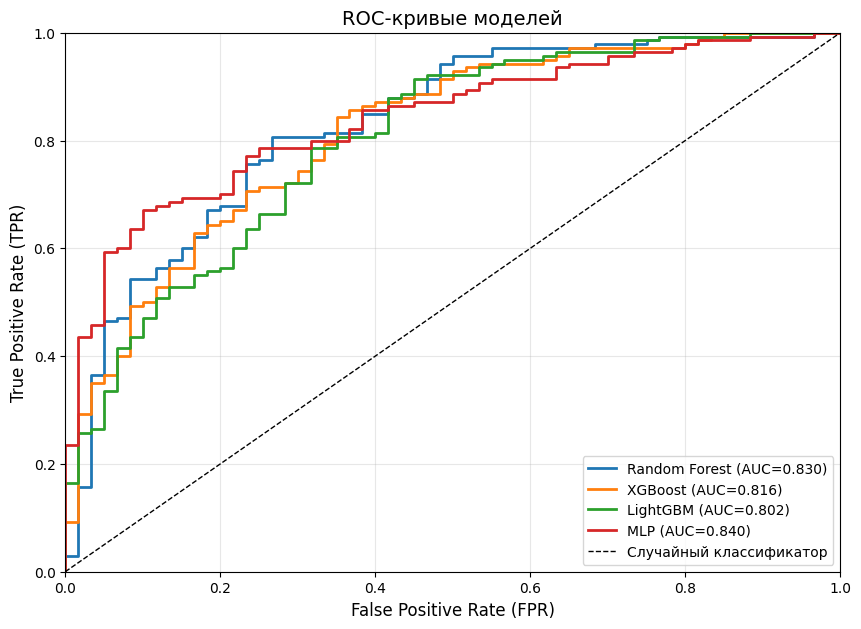


=== Лучшая модель: MLP ===
ROC-AUC на тесте: 0.8399

Классификационный отчет для MLP:
              precision    recall  f1-score   support

           0       0.64      0.50      0.56        60
           1       0.80      0.88      0.84       140

    accuracy                           0.77       200
   macro avg       0.72      0.69      0.70       200
weighted avg       0.75      0.77      0.76       200

Accuracy: 0.7650
Precision: 0.8039
Recall: 0.8786


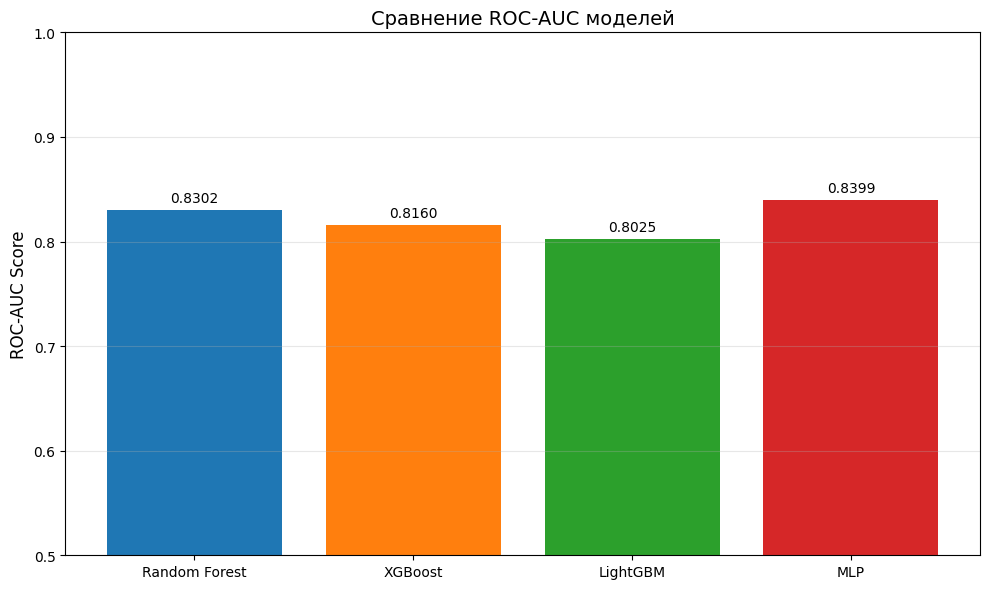

In [7]:
# 5. Сравнение результатов и визуализация (для быстрого варианта)

# Создаем DataFrame с результатами
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'LightGBM', 'MLP'],
    'Test ROC-AUC': [auc_rf, auc_xgb, auc_lgb, auc_mlp]
}).sort_values('Test ROC-AUC', ascending=False)

print("\n=== Итоговые результаты ===")
print(results)

# Визуализация ROC-кривых
plt.figure(figsize=(10, 7))

# Словарь с предсказаниями (только те модели, которые мы обучили)
models_proba = {}

# Добавляем только те модели, которые были обучены в быстром варианте
try:
    models_proba['Random Forest'] = y_proba_rf
except NameError:
    print("Random Forest не был обучен")

try:
    models_proba['XGBoost'] = y_proba_xgb
except NameError:
    print("XGBoost не был обучен")

try:
    models_proba['LightGBM'] = y_proba_lgb
except NameError:
    print("LightGBM не был обучен")

try:
    models_proba['MLP'] = y_proba_mlp
except NameError:
    print("MLP не был обучен")

# Рисуем ROC-кривые для каждой модели
for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Случайный классификатор')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC-кривые моделей', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

# Определяем лучшую модель (с максимальным AUC)
auc_values = {
    'Random Forest': auc_rf,
    'XGBoost': auc_xgb,
    'LightGBM': auc_lgb,
    'MLP': auc_mlp
}

best_model_name = max(auc_values, key=auc_values.get)
best_auc = auc_values[best_model_name]

print(f"\n=== Лучшая модель: {best_model_name} ===")
print(f"ROC-AUC на тесте: {best_auc:.4f}")

# Выводим классификационный отчет для лучшей модели
if best_model_name == 'Random Forest':
    best_model = rf_fast
elif best_model_name == 'XGBoost':
    best_model = xgb_fast
elif best_model_name == 'LightGBM':
    best_model = lgb_fast
elif best_model_name == 'MLP':
    best_model = mlp_fast

print(f"\nКлассификационный отчет для {best_model_name}:")
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))

# Дополнительная метрика - точность
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Accuracy: {accuracy_best:.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best):.4f}")

# Сравнение всех моделей в виде столбчатой диаграммы
plt.figure(figsize=(10, 6))
models_list = list(auc_values.keys())
auc_list = list(auc_values.values())

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = plt.bar(models_list, auc_list, color=colors[:len(models_list)])
plt.ylim([0.5, 1.0])
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.title('Сравнение ROC-AUC моделей', fontsize=14)
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar, auc_val in zip(bars, auc_list):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{auc_val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Экспериментируйте
Для получения лучшего качества придется поэкспериментировать. Подсказка: попробуйте оптимизировать гиперпараметры модели